In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# Загружаем данные ирисов Фишера
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Создаем DataFrame для удобства
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['target_name'] = df['target'].map({i: name for i, name in enumerate(target_names)})

print("Первые 5 строк данных:")
print(df.head())
print(f"\nРазмер данных: {df.shape}")

print(f"Классы: {target_names}")

Первые 5 строк данных:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_name  
0       0      setosa  
1       0      setosa  
2       0      setosa  
3       0      setosa  
4       0      setosa  

Размер данных: (150, 6)
Классы: ['setosa' 'versicolor' 'virginica']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Обучающая выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка: {X_test.shape[0]} объектов")
print(f"\nРаспределение классов в обучающей выборке:")
print(pd.Series(y_train).value_counts().sort_index())

Обучающая выборка: 105 объектов
Тестовая выборка: 45 объектов

Распределение классов в обучающей выборке:
0    35
1    35
2    35
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Обучающая выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка: {X_test.shape[0]} объектов")
print(f"\nРаспределение классов в обучающей выборке:")
print(pd.Series(y_train).value_counts().sort_index())

Обучающая выборка: 105 объектов
Тестовая выборка: 45 объектов

Распределение классов в обучающей выборке:
0    35
1    35
2    35
Name: count, dtype: int64


In [ ]:
clf = DecisionTreeClassifier(max_depth=3, random_state=42)  
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Точность на тестовой выборке: {accuracy:.3f}")
print(f"\nМатрица ошибок:")
print(confusion_matrix(y_test, y_pred))

Точность на тестовой выборке: 0.978

Матрица ошибок:
[[15  0  0]
 [ 0 14  1]
 [ 0  0 15]]


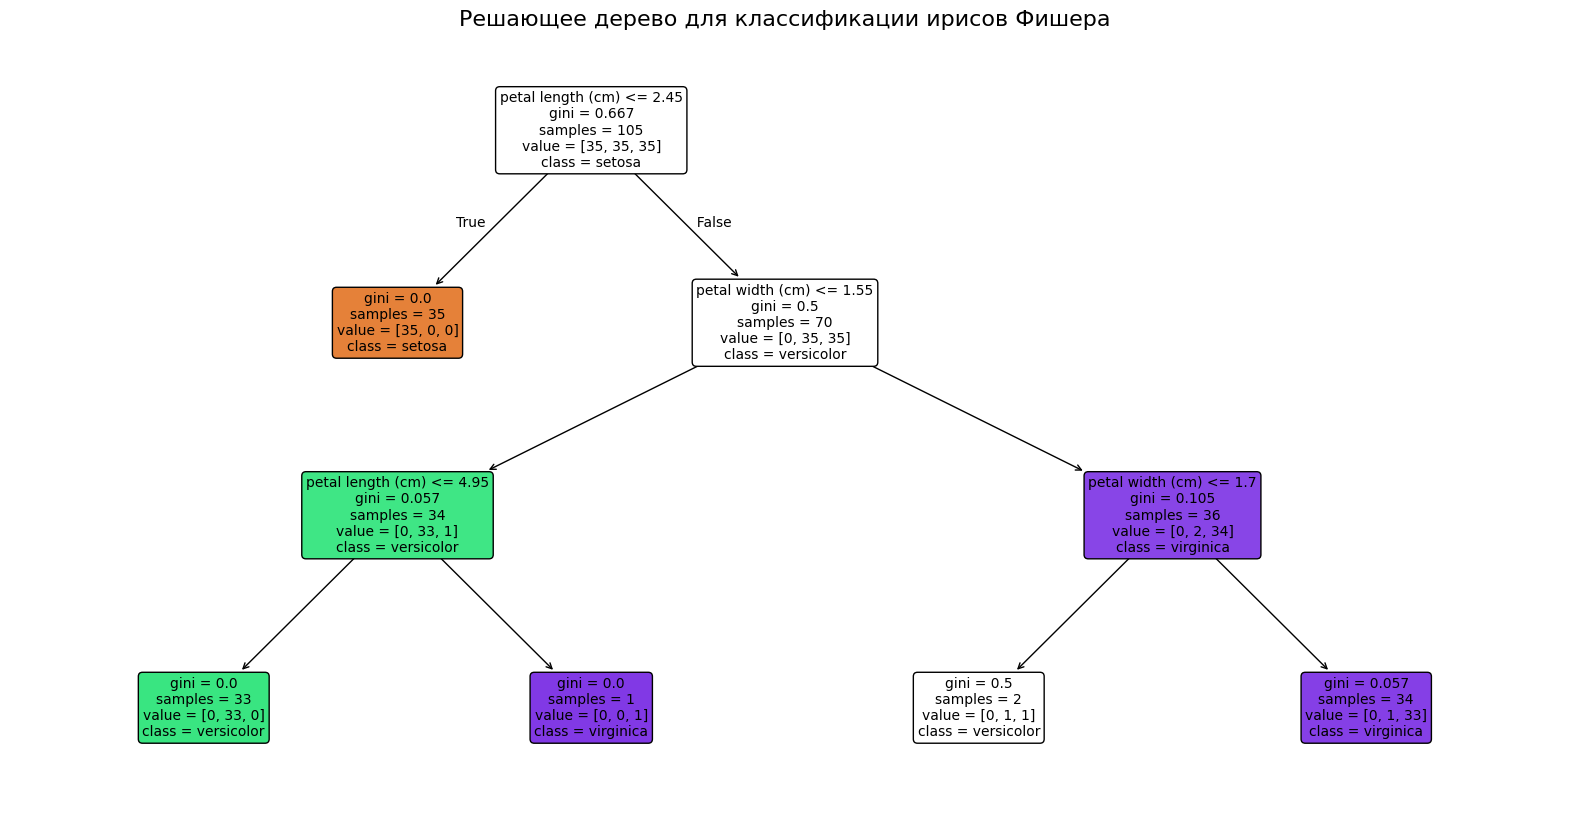

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(clf, 
          feature_names=feature_names,
          class_names=target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Решающее дерево для классификации ирисов Фишера", fontsize=16)
plt.show()

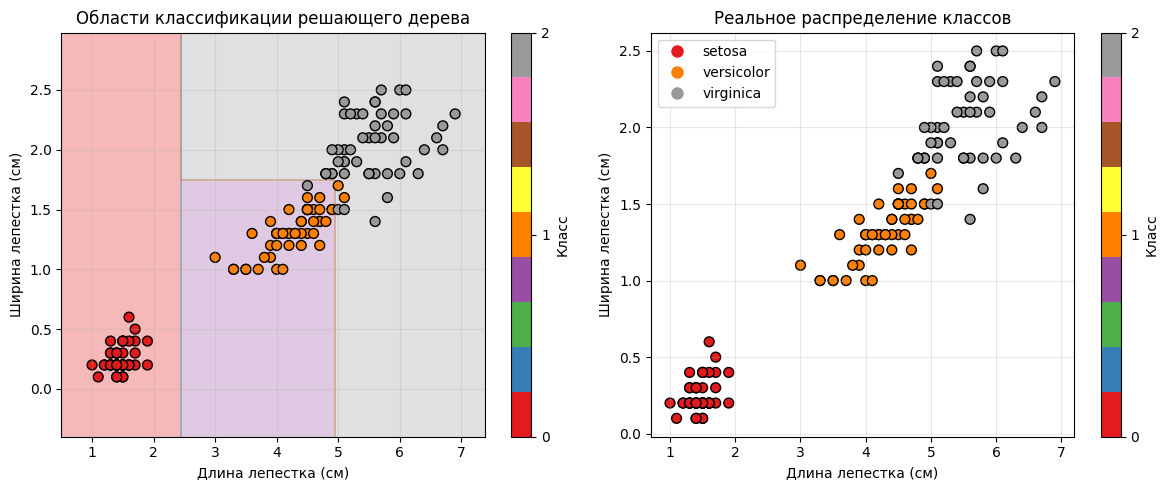

In [ ]:
X_2d = X[:, [2, 3]]  
clf_2d = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_2d.fit(X_2d, y)

x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(12, 5))

# График 1: Области классификации
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='Set1', edgecolor='black', s=50)
plt.xlabel('Длина лепестка (см)')
plt.ylabel('Ширина лепестка (см)')
plt.title('Области классификации решающего дерева')
plt.colorbar(ticks=[0, 1, 2], label='Класс')
plt.grid(True, alpha=0.3)

# График 2: Реальное распределение
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='Set1', edgecolor='black', s=50)
plt.xlabel('Длина лепестка (см)')
plt.ylabel('Ширина лепестка (см)')
plt.title('Реальное распределение классов')
plt.colorbar(scatter, ticks=[0, 1, 2], label='Класс')
plt.grid(True, alpha=0.3)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.Set1(i/2), 
                      markersize=10, label=target_names[i]) for i in range(3)]
plt.legend(handles=handles, loc='upper left')

plt.tight_layout()
plt.show()

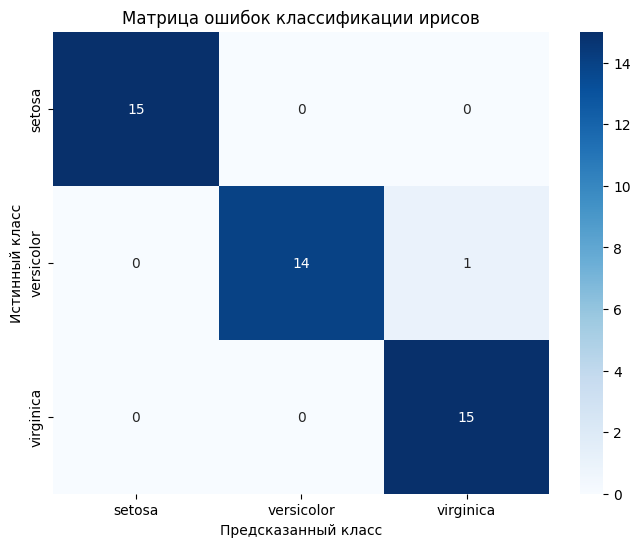

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title('Матрица ошибок классификации ирисов')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()